In [2]:
# !pip install transformers datasets scikit-learn torch evaluate accelerate
# !pip install sentencepiece  # needed for some tokenizers

# Core imports
import random
import numpy as np
import pandas as pd

# HuggingFace
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

# runtime tracking
from tqdm import tqdm

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# device selection
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

c:\Users\himik\OneDrive\Documents\University\4NL3\project-4nl3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [ ]:
from datasets import Dataset

train_data_path = "../data/training_data.csv"
train_label_path = "../data/training_label.csv"
test_data_path = "../data/testing_data.csv"
test_label_path = "../data/testing_label.csv"


train_data = pd.read_csv(train_data_path)[0:200000]
train_label = pd.read_csv(train_label_path)[0:200000]
test_data = pd.read_csv(test_data_path)[0:50000]
test_label = pd.read_csv(test_label_path)[0:50000]

train_df = pd.concat([train_data, train_label], axis=1)
train_df["question_title"] = train_df["question_title"].fillna("")
train_df["question_content"] = train_df["question_content"].fillna("")
train_df["class_index"] = train_df["class_index"] - 1
test_df = pd.concat([test_data, test_label], axis=1)
test_df["question_title"] = test_df["question_title"].fillna("")
test_df["question_content"] = test_df["question_content"].fillna("")
test_df["class_index"] = test_df["class_index"] - 1

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)


In [13]:
print("============== Train data ==============")
print(train_data.head())
print(train_data.info())
print(train_data.describe())
print()
print("============== Train label ==============")
print(train_label.head())
print(train_label.info())
print(train_label.describe())
print()
print("============== Test data ==============")
print(test_data.head())
print(test_data.info())
print(test_data.describe())
print()
print("============== Test label ==============")
print(test_label.head())
print(test_label.info())
print(test_label.describe())

============== Train data ==============
                                      question_title  \
0  why doesn't an optical mouse work on a glass t...   
1       What is the best off-road motorcycle trail ?   
2             What is Trans Fat? How to reduce that?   
3                         How many planes Fedex has?   
4  In the san francisco bay area, does it make se...   

                                    question_content  
0                          or even on some surfaces?  
1                  long-distance trail throughout CA  
2  I heard that tras fat is bad for the body.  Wh...  
3  I heard that it is the largest airline in the ...  
4  the prices of rent and the price of buying doe...  
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   question_title    200000 non-null  str  
 1   question_content  78606 non-null   str  
dtypes: s

In [14]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name, force_download=True)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=10,force_download=True)
model.to(device)

c:\Users\himik\OneDrive\Documents\University\4NL3\project-4nl3\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
 

In [15]:
# Tokenize the dataset
def tokenize(batch):
    tokenized = tokenizer(
        batch["question_title"],
        batch["question_content"],
        padding=True,
        truncation=True,
        max_length=128
    )
    if "class_index" in batch:
        tokenized["labels"] = batch["class_index"]
    return tokenized

# train_dataset = train_dataset.map(tokenize, batched=True, remove_columns=["question_title", "question_content", "class_index"])
# test_dataset = test_dataset.map(tokenize, batched=True, remove_columns=["question_title", "question_content", "class_index"])


import os
from datasets import load_from_disk

if os.path.exists("tokenized_train"):
    tokenized_train = load_from_disk("tokenized_train")
    print("Tokenized train dataset loaded from disk")
else:
    tokenized_train = train_dataset.map(tokenize, batched=True, remove_columns=["question_title", "question_content", "class_index"])
    tokenized_train.save_to_disk("tokenized_train")

if os.path.exists("tokenized_test"):
    tokenized_test = load_from_disk("tokenized_test")
    print("Tokenized test dataset loaded from disk")
else:
    tokenized_test = test_dataset.map(tokenize, batched=True, remove_columns=["question_title", "question_content", "class_index"])
    tokenized_test.save_to_disk("tokenized_test")

split = tokenized_train.train_test_split(test_size=0.1, seed=42)
train_split = split["train"]
val_split = split["test"]

print("Train labels:", train_df["class_index"].unique())
print("Min:", train_df["class_index"].min(), "Max:", train_df["class_index"].max())



Tokenized train dataset loaded from disk
Tokenized test dataset loaded from disk
Train labels: [4 5 2 6 1 7 3 8 9 0]
Min: 0 Max: 9


=== Training Set Distribution ===
class_index
0    13316
1    20988
2    17631
3    19685
4    22338
5    14741
6    46866
7    13310
8    15093
9    16032
Name: count, dtype: int64
Total: 200000

=== Test Set Distribution ===
class_index
0    4841
1    5193
2    4953
3    5088
4    5024
5    4637
6    5429
7    4853
8    4990
9    4992
Name: count, dtype: int64
Total: 50000

=== Train Split (90%) Distribution ===
1     125954
2     126121
3     126090
4     126111
5     125769
6     126093
7     125963
8     126036
9     125789
10    126073
Name: count, dtype: int64
Total: 1259999

=== Validation Split (10%) Distribution ===
1     14046
2     13879
3     13910
4     13888
5     14231
6     13907
7     14037
8     13964
9     14211
10    13927
Name: count, dtype: int64
Total: 140000



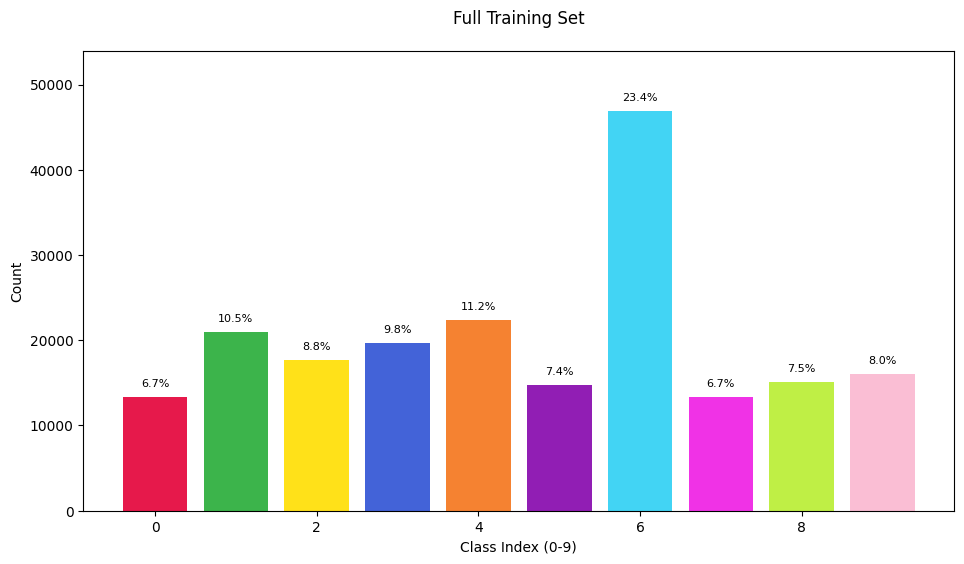

Saved: dist_train_full.png


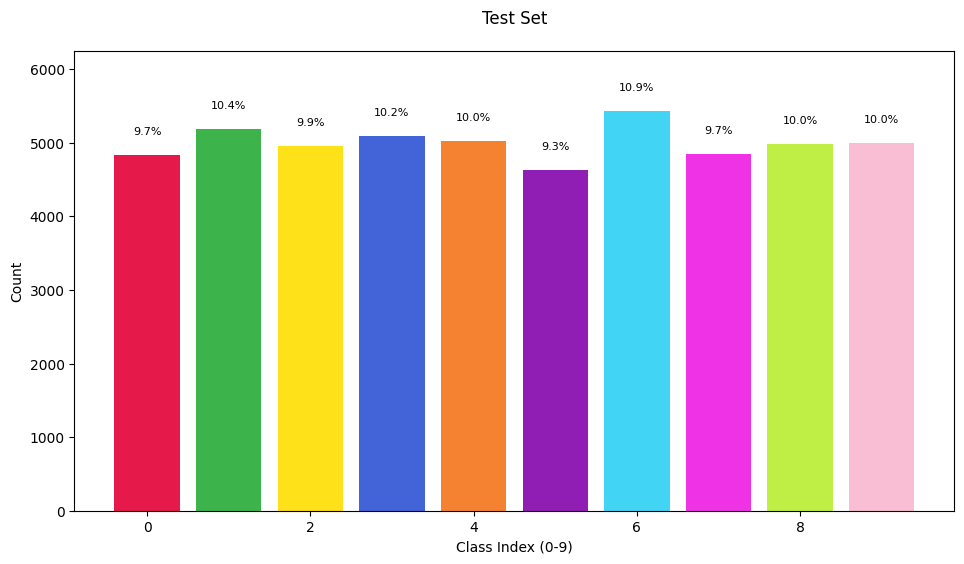

Saved: dist_test.png


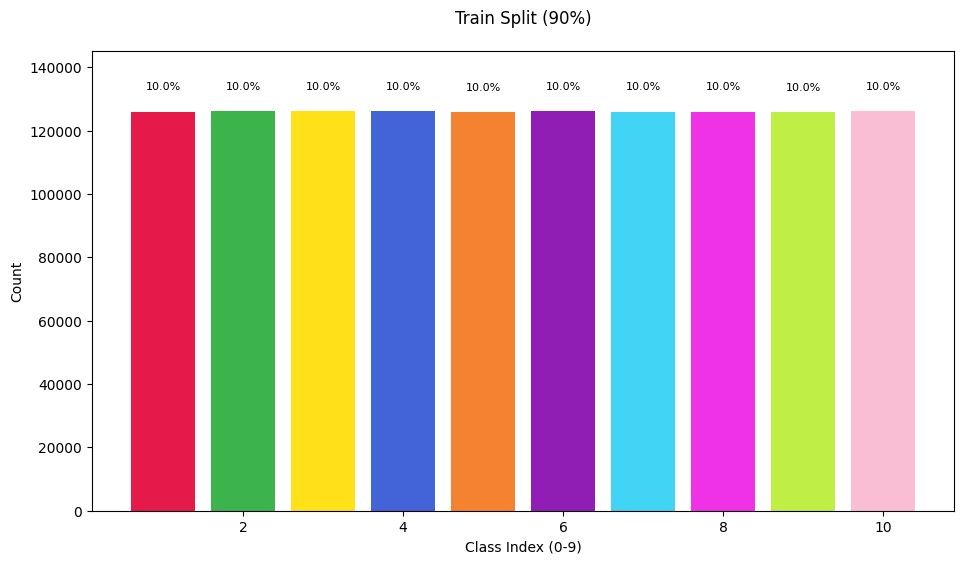

Saved: dist_train_split.png


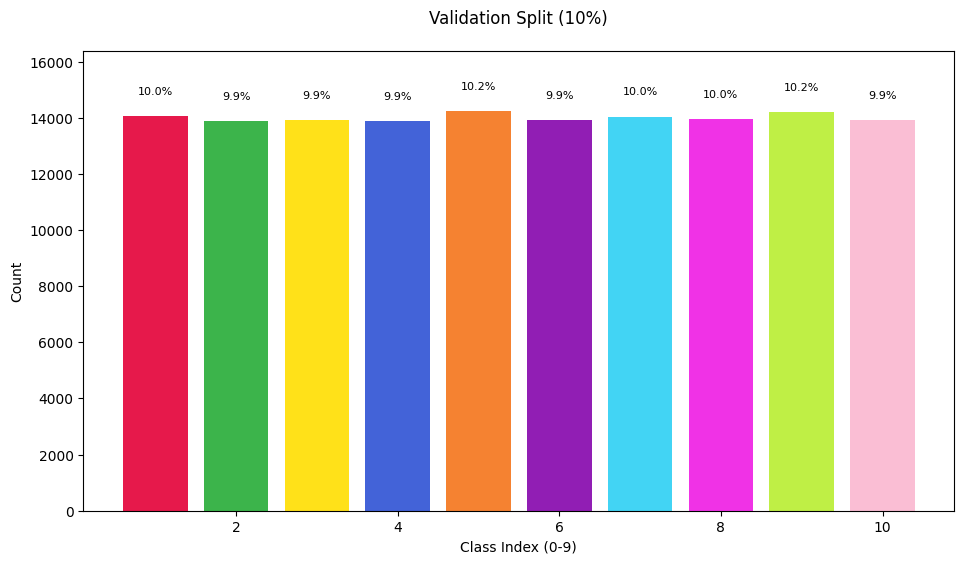

Saved: dist_val_split.png


In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Check class distribution in each split
print("=== Training Set Distribution ===")
print(train_df["class_index"].value_counts().sort_index())
print(f"Total: {len(train_df)}\n")

print("=== Test Set Distribution ===")
print(test_df["class_index"].value_counts().sort_index())
print(f"Total: {len(test_df)}\n")

print("=== Train Split (90%) Distribution ===")
train_labels_fast = pd.Series(train_split["labels"]).value_counts().sort_index()
print(train_labels_fast)
print(f"Total: {len(train_split)}\n")

print("=== Validation Split (10%) Distribution ===")
val_labels_fast = pd.Series(val_split["labels"]).value_counts().sort_index()
print(val_labels_fast)
print(f"Total: {len(val_split)}\n")

colors = ['#e6194b','#3cb44b','#ffe119','#4363d8','#f58231',
          '#911eb4','#42d4f4','#f032e6','#bfef45','#fabed4']

def add_percentages(ax, values):
    total = sum(values)
    for bar, val in zip(ax.patches, values):
        pct = f"{val/total*100:.1f}%"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.005,
                pct, ha='center', va='bottom', fontsize=8, rotation=0)

def save_distribution(counts, title, filename):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_title(title, pad=20)
    ax.set_xlabel("Class Index (0-9)")
    ax.set_ylabel("Count")
    add_percentages(ax, counts.values)
    # Add extra headroom above the bars
    ax.set_ylim(0, max(counts.values) * 1.15)
    plt.tight_layout(pad=2.0)
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {filename}")

# Full Training Set
train_counts = train_df["class_index"].value_counts().sort_index()
save_distribution(train_counts, "Full Training Set", "dist_train_full.png")

# Test Set
test_counts = test_df["class_index"].value_counts().sort_index()
save_distribution(test_counts, "Test Set", "dist_test.png")

# Train Split (90%)
train_split_counts = pd.Series(train_split["labels"]).value_counts().sort_index()
save_distribution(train_split_counts, "Train Split (90%)", "dist_train_split.png")

# Validation Split (10%)
val_split_counts = pd.Series(val_split["labels"]).value_counts().sort_index()
save_distribution(val_split_counts, "Validation Split (10%)", "dist_val_split.png")

In [11]:
# Check raw CSV before any sampling
raw_train = pd.read_csv(train_label_path)
print("=== Full Raw Training Label Distribution ===")
print(raw_train["class_index"].value_counts().sort_index())
print(raw_train["class_index"].value_counts())
print(raw_train["class_index"])
print(f"Total: {len(raw_train)}\n")

# Double check your sampled train_df
print("=== Sampled train_df Distribution ===")
print(train_df["class_index"].value_counts().sort_index())
print(f"Total: {len(train_df)}\n")

# Double check your sampled test_df
print("=== Sampled test_df Distribution ===")
print(test_df["class_index"].value_counts().sort_index())
print(f"Total: {len(test_df)}\n")

=== Full Raw Training Label Distribution ===
class_index
1     140000
2     140000
3     140000
4     139999
5     140000
6     140000
7     140000
8     140000
9     140000
10    140000
Name: count, dtype: int64
class_index
5     140000
6     140000
3     140000
7     140000
2     140000
8     140000
9     140000
10    140000
1     140000
4     139999
Name: count, dtype: int64
0          5
1          6
2          3
3          7
4          7
          ..
1399994    3
1399995    7
1399996    3
1399997    1
1399998    5
Name: class_index, Length: 1399999, dtype: int64
Total: 1399999

=== Sampled train_df Distribution ===
class_index
0    140000
1    140000
2    140000
3    139999
4    140000
5    140000
6    140000
7    140000
8    140000
9    140000
Name: count, dtype: int64
Total: 1399999

=== Sampled test_df Distribution ===
class_index
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    5999
9    6000
Name: count, dtype: int64
Total: 59999



In [6]:
from transformers import DataCollatorWithPadding
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted"),
    }

training_args = TrainingArguments(
    output_dir="model_results",
    per_device_train_batch_size=16,   # increase from 4
    gradient_accumulation_steps=2,    # 32x2=64 effective batch size
    gradient_checkpointing=False,     # turn off, hurts speed and not needed now
    fp16=True,
    num_train_epochs=5,               # add this explicitly
    learning_rate=2e-5,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    seed=42,
    save_strategy="steps",
    save_steps=200,
    eval_strategy="steps",
    eval_steps=200,
    save_total_limit=3,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_split,
    eval_dataset=val_split,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)





In [7]:
# For testing GPU memory allocation

# import torch
# batch = next(iter(trainer.get_train_dataloader()))
# print({k: v.shape for k, v in batch.items()})
# print("labels:", batch["labels"])
# print("input_ids min/max:", batch["input_ids"].min(), batch["input_ids"].max())

# # Try a manual forward pass to get the real error
# model.train()
# with torch.cuda.amp.autocast():
#     outputs = model(**batch)

In [8]:
last_checkpoint = None
if os.path.isdir(model_name):
    checkpoints = [f for f in os.listdir(model_name) if f.startswith("checkpoint")]
    if checkpoints:
        last_checkpoint = os.path.join(model_name, sorted(checkpoints)[-1])
        print(f"Resuming from {last_checkpoint}")
    else:
        print("No checkpoints found, starting fresh")
else:
    print("Starting fresh")
    
trainer.train(resume_from_checkpoint=last_checkpoint)

Starting fresh


  0%|          | 0/196875 [00:00<?, ?it/s]

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
